In [21]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time
from model_solver import MacrophageModel, Params

# Define a function to generate base parameters so we always start clean
def get_base_params(J=10, N=10, tol=1e-6):
    return Params(
        J=J, 
        N=N, 
        kplus=10, kminus=3.5, D_max=1, D_min=0.1, gamma=0.2,
        sigma_b=0.005, sigma_max=0.5, sigma_l=0.8, sigma_w=0.8, sigma_H=0.8,
        alpha=0.6, V_tot=100000, v_max=10, theta=10, tol=tol
    )

t_span = (0, 10.0)
t_eval = np.linspace(*t_span, 50)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Spatial Grid Independence ($M$)
We test whether the spatial resolution affects the final cell density profile. If the model is grid-independent, the curves for finer grids (higher $M$) should overlap.

In [22]:
J_values = [25, 50, 100]

# Dictionary to just store the spatial arrays for each J
spatial_results = {}

for J in J_values:
    # Setup model with current M
    print(f"Simulating J = {J}...")
    p = get_base_params(J=J)
    model = MacrophageModel(p)
    
    # 2. Run simulation (starting with empty domain)
    u0 = np.zeros((J + 1, p.N + 4))
    u0[:,p.N+2:p.N+4] = 1.0
    y0 = u0.ravel()
    U, _ = model.solve(t_span, t_eval, y0=y0)
    
    # 3. Compute diagnostics
    diagnostics = model.compute_diagnostics(U)
    spatial_results[J] = diagnostics["spatial"]
    

Simulating J = 25...
Simulating J = 50...
Simulating J = 100...


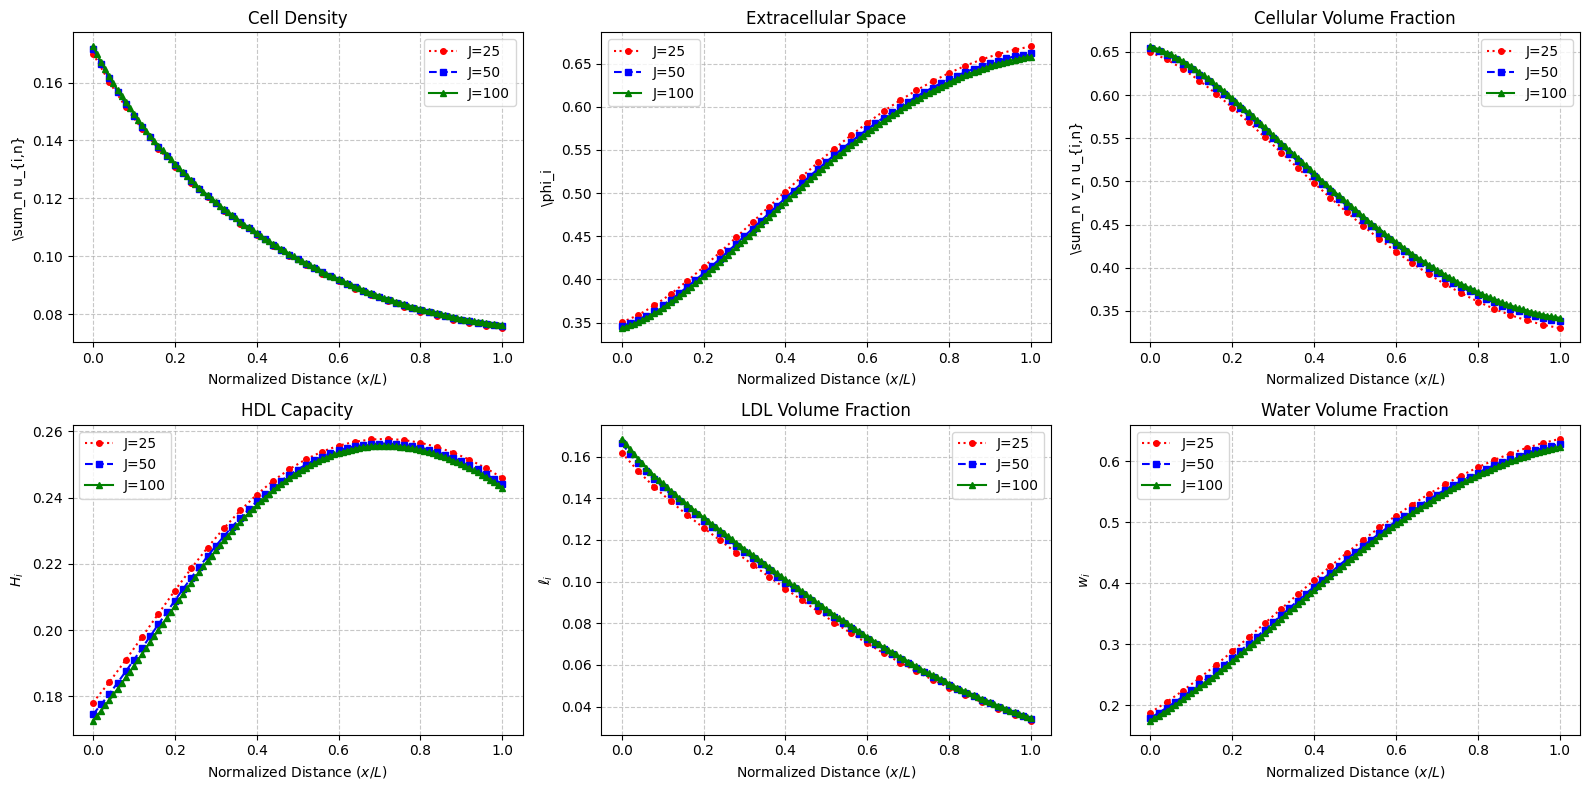

In [23]:
# 3. Plot the Spatial Profiles Side-by-Side (WITH MARKERS)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

colors = {25: 'red', 50: 'blue', 100: 'green'}
line_styles = {25: ':', 50: '--', 100: '-'}
# NEW: Define a unique marker shape for each grid resolution
markers = {25: 'o', 50: 's', 100: '^'}  # Circle, Square, Triangle

for J in J_values:
    normalized_x = np.linspace(0, 1.0, J + 1)
    
    u_profile = spatial_results[J]["cell_density"][-1, :]
    phi_profile = spatial_results[J]["phi"][-1, :]
    vu_profile = spatial_results[J]["volume_fraction"][-1, :]
    H_profile = spatial_results[J]["HDL_capacity"][-1, :]
    l_profile = spatial_results[J]["LDL_volume_fraction"][-1, :]
    w_profile = spatial_results[J]["water_volume_fraction"][-1, :]
    
    # Added marker and markersize to each plot
    axes[0].plot(normalized_x, u_profile, label=f'J={J}', 
                 color=colors[J], linestyle=line_styles[J], linewidth=1.5,
                 marker=markers[J], markersize=4)
    
    axes[1].plot(normalized_x, phi_profile, label=f'J={J}', 
                 color=colors[J], linestyle=line_styles[J], linewidth=1.5,
                 marker=markers[J], markersize=4)
    
    axes[2].plot(normalized_x, vu_profile, label=f'J={J}', 
                 color=colors[J], linestyle=line_styles[J], linewidth=1.5,
                 marker=markers[J], markersize=4)
    
    axes[3].plot(normalized_x, H_profile, label=f'J={J}', 
                 color=colors[J], linestyle=line_styles[J], linewidth=1.5,
                 marker=markers[J], markersize=4)
    
    axes[4].plot(normalized_x, l_profile, label=f'J={J}', 
                 color=colors[J], linestyle=line_styles[J], linewidth=1.5,
                 marker=markers[J], markersize=4)
    
    axes[5].plot(normalized_x, w_profile, label=f'J={J}', 
                 color=colors[J], linestyle=line_styles[J], linewidth=1.5,
                 marker=markers[J], markersize=4)

# Format the plots
axes[0].set_title("Cell Density")
axes[0].set_ylabel(r"\sum_n u_{i,n}")

axes[1].set_title(r"Extracellular Space")
axes[1].set_ylabel(r"\phi_i")

axes[2].set_title("Cellular Volume Fraction")
axes[2].set_ylabel(r"\sum_n v_n u_{i,n}")

axes[3].set_title("HDL Capacity")
axes[3].set_ylabel("$H_i$")

axes[4].set_title(r"LDL Volume Fraction")
axes[4].set_ylabel(r"$\ell_i$")

axes[5].set_title("Water Volume Fraction")
axes[5].set_ylabel("$w_i$")

for ax in axes:
    ax.set_xlabel("Normalized Distance ($x/L$)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Structure Grid Independence ($N$)
We test whether the lipid class resolution affects the final lipid distribution within the cells.

In [24]:
N_values = [25, 50, 100]
structural_results = {}

for N in N_values:
    print(f"Simulating N = {N}...")
    p = get_base_params(N=N)
    model = MacrophageModel(p)
    
    u0 = np.zeros((p.J + 1, p.N + 4))
    u0[:,N+2:N+4] = 1.0
    y0 = u0.ravel()
    U, _ = model.solve(t_span, t_eval, y0=y0)
    
    diagnostics = model.compute_diagnostics(U)
    structural_results[N] = diagnostics["structure"]

Simulating N = 25...
Simulating N = 50...


KeyboardInterrupt: 

In [ ]:
# Plot the Structure Profiles Side-by-Side (WITH MARKERS)
plt.figure(figsize=(8, 5))

colors = {25: 'red', 50: 'blue', 100: 'green'}
line_styles = {25: ':', 50: '--', 100: '-'}
markers = {25: 'o', 50: 's', 100: '^'}  # Circle, Square, Triangle

for N in N_values:
    s = np.linspace(0, 1.0, N + 1)
    
    u_profile = structural_results[N]["average_cell_density"][-1, :]
    
    # Added marker and markersize to each plot
    plt.plot(s, N*u_profile, label=f'N={N}', 
                 color=colors[N], linestyle=line_styles[N], linewidth=1.5,
                 marker=markers[N], markersize=6)


# Format the plots
plt.title("Average Cell Density ($u$)")
plt.ylabel("Dimensionless Concentration")
plt.xlabel("Lipid load ($s$)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

KeyError: 'cell_density'

<Figure size 800x500 with 0 Axes>

## Solver Tolerance Sensitivity
We measure how the relative tolerance (`tol`) of the BDF solver impacts both execution time and the precision of the total macrophage count.

Tolerance       | Execution Time (s)   | Final Total Macrophages  
-----------------------------------------------------------------
1e-03           | 0.0460               | 7928.882468              
1e-04           | 0.0520               | 7928.906342              
1e-05           | 0.0631               | 7928.915663              
1e-06           | 0.0719               | 7928.915787              
1e-07           | 0.0919               | 7928.915938              


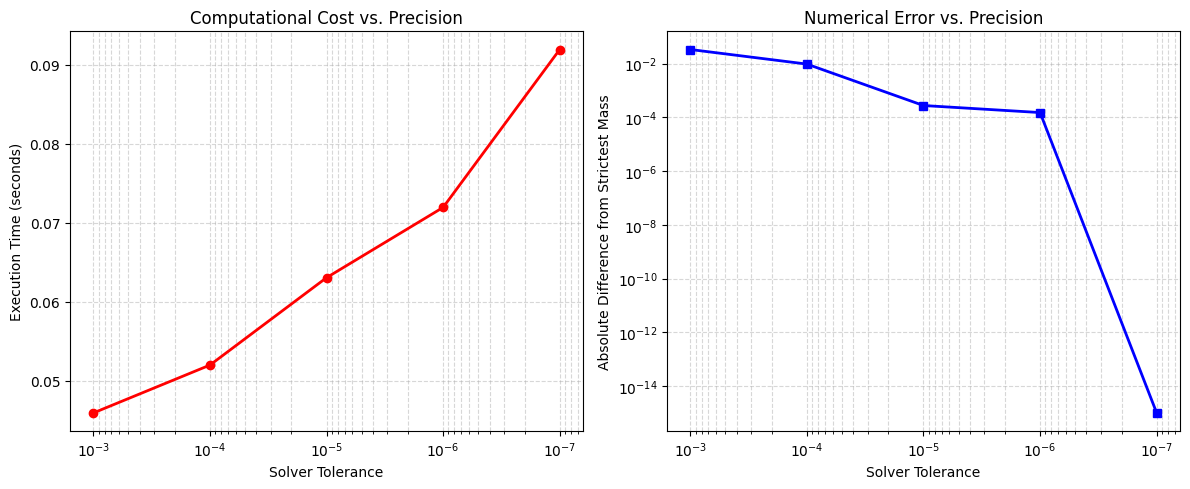

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

# We use a slightly wider range of tolerances to get a good plot
tolerances = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7]

execution_times = []
final_masses = []

print(f"{'Tolerance':<15} | {'Execution Time (s)':<20} | {'Final Total Macrophages':<25}")
print("-" * 65)

# 1. Run the solver for each tolerance
for tol in tolerances:
    p = get_base_params(tol=tol)
    model = MacrophageModel(p)
    
    u0 = np.zeros((p.M + 1, p.N + 1)).ravel()
    
    start_time = time.time()
    U, _ = model.solve(t_span, t_eval, y0=u0)
    end_time = time.time()
    
    diagnostics = model.compute_diagnostics(U)
    final_total = diagnostics["totals"]["macrophage_number"][-1]
    
    elapsed = end_time - start_time
    execution_times.append(elapsed)
    final_masses.append(final_total)
    
    print(f"{tol:<15.0e} | {elapsed:<20.4f} | {final_total:<25.6f}")

# 2. Assume the strictest tolerance (1e-7) is our "Ground Truth"
ground_truth_mass = final_masses[-1]

# Calculate the absolute error for each run compared to the ground truth
errors = [abs(mass - ground_truth_mass) for mass in final_masses]

# 3. Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Execution Time
ax1.plot(tolerances, execution_times, marker='o', color='red', linewidth=2)
ax1.set_xscale('log')
ax1.invert_xaxis() # We invert so stricter tolerance (smaller number) is on the right
ax1.set_title("Computational Cost vs. Precision")
ax1.set_xlabel("Solver Tolerance")
ax1.set_ylabel("Execution Time (seconds)")
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Plot 2: Mass Error
# We replace exact 0.0 error with a tiny number so it plots on a log scale
safe_errors = [e if e > 0 else 1e-15 for e in errors] 
ax2.plot(tolerances, safe_errors, marker='s', color='blue', linewidth=2)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.invert_xaxis()
ax2.set_title("Numerical Error vs. Precision")
ax2.set_xlabel("Solver Tolerance")
ax2.set_ylabel("Absolute Difference from Strictest Mass")
ax2.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()